# A/B Testing & Experimentation

A/B testing is the gold standard for causal inference — a **randomized controlled experiment** that cleanly isolates the effect of a single change. Every major tech company runs hundreds of experiments simultaneously; understanding experimentation statistics is a core data science skill.

## What You'll Learn
- Hypothesis testing fundamentals (null hypothesis, p-values, Type I/II errors)
- Two-sample z-test and t-test from scratch
- Statistical power and sample size calculations
- Multiple testing correction (Bonferroni, Benjamini-Hochberg)
- Common pitfalls: peeking, novelty effects, Simpson's paradox
- Bayesian A/B testing
- Multi-armed bandits as an adaptive alternative
- End-to-end experiment simulation

## Real-World Impact
Netflix A/B tested their thumbnail artwork and found a 20-35% increase in engagement. Amazon tests everything from button colors to checkout flows. Without proper experimentation, you can't tell if changes help or hurt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm, beta as beta_dist
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


---
## 1. Hypothesis Testing Framework

**Setup:**
- $H_0$: No difference between variants (null hypothesis)
- $H_1$: There is a difference (alternative hypothesis)
- $\alpha$: Significance level (Type I error rate) — typically 0.05
- $\beta$: Type II error rate — typically 0.20, giving **power** $= 1-\beta = 0.80$

**Decision rule:** Reject $H_0$ if $p$-value $< \alpha$.

| | $H_0$ True | $H_0$ False |
|---|---|---|
| **Reject $H_0$** | Type I Error (FP, rate=$\alpha$) | Correct (Power=$1-\beta$) |
| **Fail to Reject $H_0$** | Correct (Specificity=$1-\alpha$) | Type II Error (FN, rate=$\beta$) |

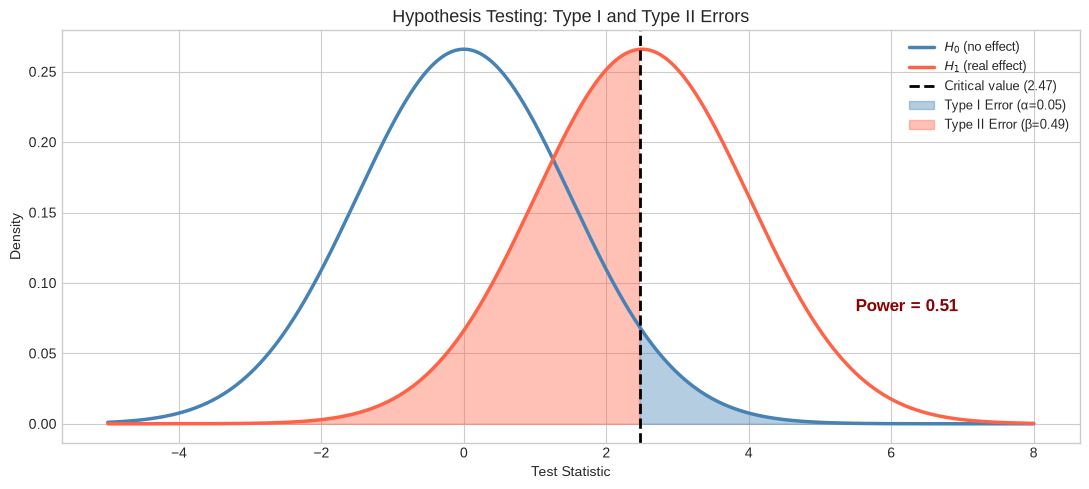

Critical value:  2.467
Power (1-β):     0.509


In [2]:
# Visualize Type I and Type II errors
fig, ax = plt.subplots(figsize=(11, 5))

x = np.linspace(-5, 8, 1000)
mu_null = 0    # null distribution mean
mu_alt = 2.5   # alternative distribution mean
sigma = 1.5
alpha = 0.05

critical_val = norm.ppf(1 - alpha, mu_null, sigma)

null_pdf = norm.pdf(x, mu_null, sigma)
alt_pdf = norm.pdf(x, mu_alt, sigma)

ax.plot(x, null_pdf, 'steelblue', linewidth=2.5, label=r'$H_0$ (no effect)')
ax.plot(x, alt_pdf, 'tomato', linewidth=2.5, label=r'$H_1$ (real effect)')
ax.axvline(critical_val, color='black', linewidth=2, linestyle='--', label=f'Critical value ({critical_val:.2f})')

# Type I error region (alpha)
x_alpha = x[x >= critical_val]
ax.fill_between(x_alpha, norm.pdf(x_alpha, mu_null, sigma), alpha=0.4, color='steelblue', label=f'Type I Error (α={alpha})')

# Type II error region (beta)
x_beta = x[x <= critical_val]
ax.fill_between(x_beta, norm.pdf(x_beta, mu_alt, sigma), alpha=0.4, color='tomato', label=f'Type II Error (β={norm.cdf(critical_val, mu_alt, sigma):.2f})')

power = 1 - norm.cdf(critical_val, mu_alt, sigma)
ax.text(5.5, 0.08, f'Power = {power:.2f}', fontsize=12, color='darkred', fontweight='bold')
ax.set_title('Hypothesis Testing: Type I and Type II Errors', fontsize=13)
ax.set_xlabel('Test Statistic')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('hypothesis_testing.png', dpi=80, bbox_inches='tight')
plt.show()

print(f'Critical value:  {critical_val:.3f}')
print(f'Power (1-β):     {power:.3f}')

---
## 2. Two-Sample Z-Test From Scratch (Proportions)

For comparing conversion rates between control (A) and treatment (B):

$$z = \frac{\hat{p}_B - \hat{p}_A}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_A} + \frac{1}{n_B}\right)}}$$

where $\hat{p} = \frac{x_A + x_B}{n_A + n_B}$ is the pooled proportion.

In [3]:
def two_proportion_ztest(n_a, conv_a, n_b, conv_b, alpha=0.05):
    """Two-sample z-test for proportions (two-tailed)."""
    p_a = conv_a / n_a
    p_b = conv_b / n_b
    p_pool = (conv_a + conv_b) / (n_a + n_b)

    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
    z_stat = (p_b - p_a) / se
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    ci_low = (p_b - p_a) - norm.ppf(1 - alpha/2) * np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
    ci_high = (p_b - p_a) + norm.ppf(1 - alpha/2) * np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)

    return {
        'p_a': p_a, 'p_b': p_b, 'lift': (p_b - p_a)/p_a,
        'z': z_stat, 'p_value': p_value,
        'ci': (ci_low, ci_high),
        'significant': p_value < alpha
    }


# Simulate an A/B test: website button color
# Control (A): blue button
# Treatment (B): green button
true_p_a = 0.10   # 10% baseline conversion
true_p_b = 0.115  # 15% relative lift
n_per_group = 2000

np.random.seed(42)
conv_a = np.random.binomial(n_per_group, true_p_a)
conv_b = np.random.binomial(n_per_group, true_p_b)

result = two_proportion_ztest(n_per_group, conv_a, n_per_group, conv_b)

print('=== A/B Test Results ===')
print(f'Control (A):    {conv_a}/{n_per_group} = {result["p_a"]:.3%}')
print(f'Treatment (B):  {conv_b}/{n_per_group} = {result["p_b"]:.3%}')
print(f'Relative lift:  {result["lift"]:.2%}')
print(f'Z-statistic:    {result["z"]:.3f}')
print(f'P-value:        {result["p_value"]:.4f}')
print(f'95% CI (diff):  [{result["ci"][0]:.4f}, {result["ci"][1]:.4f}]')
print(f'Significant:    {result["significant"]}')

=== A/B Test Results ===
Control (A):    191/2000 = 9.550%
Treatment (B):  220/2000 = 11.000%
Relative lift:  15.18%
Z-statistic:    1.510
P-value:        0.1310
95% CI (diff):  [-0.0043, 0.0333]
Significant:    False


---
## 3. Sample Size Calculation

How many users do you need? Given baseline rate $p_1$, minimum detectable effect (MDE) $\delta$, significance $\alpha$, and power $1-\beta$:

$$n = \frac{(z_{\alpha/2} + z_{\beta})^2 \cdot (p_1(1-p_1) + p_2(1-p_2))}{(p_2 - p_1)^2}$$

where $p_2 = p_1 + \delta$.

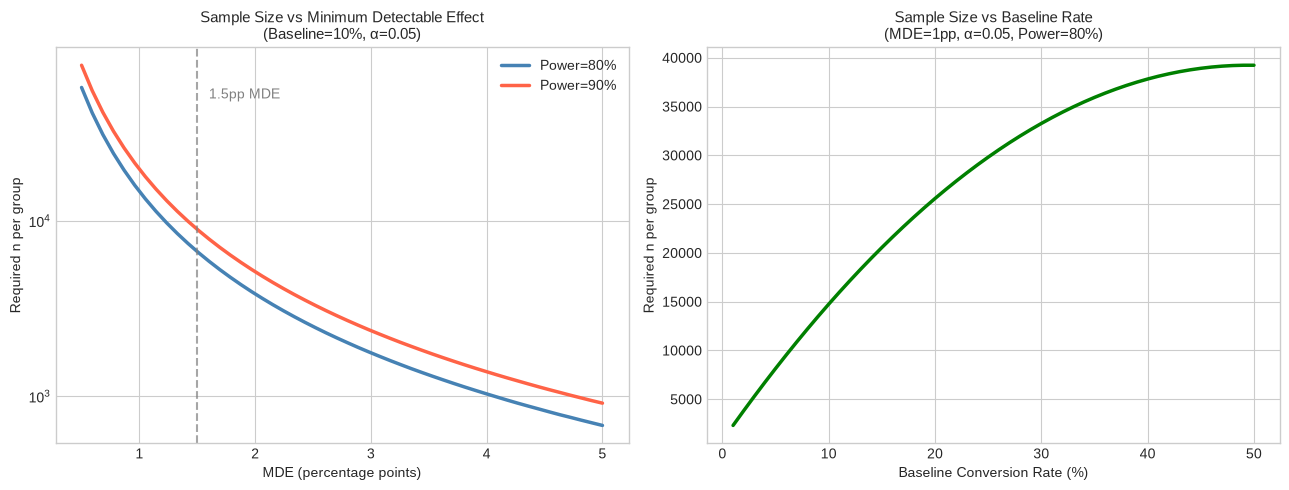

Sample size examples (α=0.05, power=80%):
  MDE=1%: n=14,749 per group (29,498 total)
  MDE=2%: n=3,839 per group (7,678 total)
  MDE=5%: n=683 per group (1,366 total)


In [4]:
def sample_size_proportions(p1, mde, alpha=0.05, power=0.80):
    """Calculate required sample size per group for two-proportion test."""
    p2 = p1 + mde
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(power)
    n = (z_alpha + z_beta)**2 * (p1*(1-p1) + p2*(1-p2)) / (p2 - p1)**2
    return int(np.ceil(n))


# How sample size changes with MDE
baseline = 0.10
mdes = np.linspace(0.005, 0.05, 50)
ns_80 = [sample_size_proportions(baseline, m, power=0.80) for m in mdes]
ns_90 = [sample_size_proportions(baseline, m, power=0.90) for m in mdes]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mdes*100, ns_80, linewidth=2.5, color='steelblue', label='Power=80%')
axes[0].plot(mdes*100, ns_90, linewidth=2.5, color='tomato', label='Power=90%')
axes[0].set_title(f'Sample Size vs Minimum Detectable Effect\n(Baseline={baseline:.0%}, α=0.05)', fontsize=11)
axes[0].set_xlabel('MDE (percentage points)')
axes[0].set_ylabel('Required n per group')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].axvline(1.5, color='gray', linestyle='--', alpha=0.7)
axes[0].text(1.6, 50000, '1.5pp MDE', color='gray')

# Sample size vs baseline rate
baselines = np.linspace(0.01, 0.50, 50)
mde_fixed = 0.01  # 1 pp MDE
ns_bl = [sample_size_proportions(b, mde_fixed) for b in baselines]
axes[1].plot(baselines*100, ns_bl, linewidth=2.5, color='green')
axes[1].set_title(f'Sample Size vs Baseline Rate\n(MDE=1pp, α=0.05, Power=80%)', fontsize=11)
axes[1].set_xlabel('Baseline Conversion Rate (%)')
axes[1].set_ylabel('Required n per group')

plt.tight_layout()
plt.savefig('sample_size_curves.png', dpi=80, bbox_inches='tight')
plt.show()

# Example calculations
print('Sample size examples (α=0.05, power=80%):')
for mde in [0.01, 0.02, 0.05]:
    n = sample_size_proportions(0.10, mde)
    print(f'  MDE={mde:.0%}: n={n:,} per group ({2*n:,} total)')

---
## 4. Common Pitfalls

### 4a. Peeking Problem (Optional Stopping)

If you repeatedly check your experiment and stop as soon as $p < 0.05$, your actual Type I error rate balloons — you'll see false positives far more than 5% of the time.

False positive rate (peeking daily):  28.07%  ← INFLATED!
False positive rate (fixed horizon):  5.13%  ← Near 5% as intended


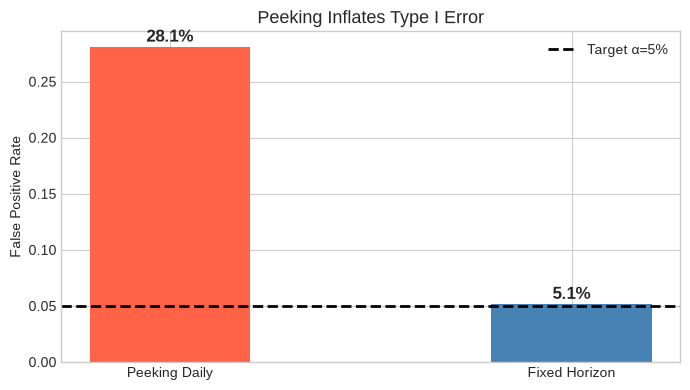

In [5]:
def simulate_peeking(n_simulations=5000, n_days=30, daily_users=200, alpha=0.05):
    """Simulate peeking: reject H0 if p<alpha at ANY check."""
    false_positives_peek = 0
    false_positives_fixed = 0
    true_p = 0.10  # same for both groups (null is true!)

    for _ in range(n_simulations):
        conv_a_total = 0
        conv_b_total = 0
        n_total = 0
        rejected_early = False

        for day in range(n_days):
            conv_a_total += np.random.binomial(daily_users, true_p)
            conv_b_total += np.random.binomial(daily_users, true_p)
            n_total += daily_users

            # Peek each day
            if n_total >= 200:  # minimum sample
                res = two_proportion_ztest(n_total, conv_a_total, n_total, conv_b_total, alpha=alpha)
                if res['significant'] and not rejected_early:
                    rejected_early = True

        if rejected_early:
            false_positives_peek += 1

        # Fixed-horizon: only look at end
        res_final = two_proportion_ztest(n_total, conv_a_total, n_total, conv_b_total, alpha=alpha)
        if res_final['significant']:
            false_positives_fixed += 1

    return false_positives_peek / n_simulations, false_positives_fixed / n_simulations

fp_peek, fp_fixed = simulate_peeking(n_simulations=3000)
print(f'False positive rate (peeking daily):  {fp_peek:.2%}  ← INFLATED!')
print(f'False positive rate (fixed horizon):  {fp_fixed:.2%}  ← Near 5% as intended')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Peeking Daily', 'Fixed Horizon'], [fp_peek, fp_fixed],
               color=['tomato', 'steelblue'], width=0.4)
ax.axhline(0.05, color='black', linestyle='--', linewidth=2, label='Target α=5%')
for bar, val in zip(bars, [fp_peek, fp_fixed]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.1%}',
            ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('False Positive Rate')
ax.set_title('Peeking Inflates Type I Error', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('peeking_problem.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 5. Multiple Testing Correction

If you test $m$ hypotheses simultaneously, the chance of at least one false positive is:
$$P(\text{at least one FP}) = 1 - (1-\alpha)^m$$

With $m=20$ tests and $\alpha=0.05$: probability ≈ 64%!

**Bonferroni correction**: use $\alpha' = \alpha/m$ — very conservative

**Benjamini-Hochberg (BH) FDR**: controls the **False Discovery Rate** instead of FWER — more powerful:
1. Sort p-values: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$
2. Find largest $k$ such that $p_{(k)} \leq \frac{k}{m} \cdot \alpha$
3. Reject all hypotheses with $p_{(i)} \leq p_{(k)}$

In [6]:
def bonferroni_correction(p_values, alpha=0.05):
    m = len(p_values)
    return p_values < (alpha / m)

def bh_correction(p_values, alpha=0.05):
    """Benjamini-Hochberg FDR correction."""
    m = len(p_values)
    order = np.argsort(p_values)
    p_sorted = p_values[order]
    thresholds = (np.arange(1, m+1) / m) * alpha
    below_threshold = p_sorted <= thresholds
    if not below_threshold.any():
        cutoff = -1
    else:
        cutoff = np.max(np.where(below_threshold)[0])
    rejected = np.zeros(m, dtype=bool)
    rejected[order[:cutoff+1]] = True
    return rejected


# Simulate 20 A/B tests: 5 real effects, 15 nulls
np.random.seed(42)
m_tests = 20
n_real = 5
true_effects = np.array([True]*n_real + [False]*(m_tests-n_real))
np.random.shuffle(true_effects)

p_values = []
for is_real in true_effects:
    if is_real:
        # Real effect: p value drawn from near 0
        p_values.append(np.random.uniform(0, 0.05))
    else:
        # Null: p value uniform on [0,1]
        p_values.append(np.random.uniform(0, 1))
p_values = np.array(p_values)

naive = p_values < 0.05
bonf = bonferroni_correction(p_values)
bh = bh_correction(p_values)

def metrics(rejected, truth):
    tp = (rejected & truth).sum()
    fp = (rejected & ~truth).sum()
    fn = (~rejected & truth).sum()
    power = tp / truth.sum() if truth.sum() > 0 else 0
    fdr = fp / rejected.sum() if rejected.sum() > 0 else 0
    return tp, fp, fn, power, fdr

print(f'{"Method":<20} {"Rejected":>9} {"TP":>4} {"FP":>4} {"FN":>4} {"Power":>8} {"FDR":>8}')
print('-' * 65)
for name, rej in [("Naive (α=0.05)", naive), ("Bonferroni", bonf), ("BH FDR (q=0.05)", bh)]:
    tp, fp, fn, power, fdr = metrics(rej, true_effects)
    print(f'{name:<20} {rej.sum():>9} {tp:>4} {fp:>4} {fn:>4} {power:>8.2%} {fdr:>8.2%}')

Method                Rejected   TP   FP   FN    Power      FDR
-----------------------------------------------------------------
Naive (α=0.05)               9    5    4    0  100.00%   44.44%
Bonferroni                   1    1    0    4   20.00%    0.00%
BH FDR (q=0.05)              3    2    1    3   40.00%   33.33%


---
## 6. Bayesian A/B Testing

Instead of p-values, Bayesian testing gives us **P(B > A)** — the probability that variant B is truly better.

For conversion rates (binary outcomes), we use the Beta distribution as a conjugate prior:
- Prior: $\theta \sim \text{Beta}(\alpha_0, \beta_0)$ (e.g., $\alpha_0=\beta_0=1$ for uniform)
- Likelihood: $x \mid \theta \sim \text{Binomial}(n, \theta)$
- Posterior: $\theta \mid x \sim \text{Beta}(\alpha_0 + x, \beta_0 + n - x)$

Then **P(B > A)** is computed by Monte Carlo sampling from both posteriors.

Bayesian P(B > A): 0.9362 (93.6%)


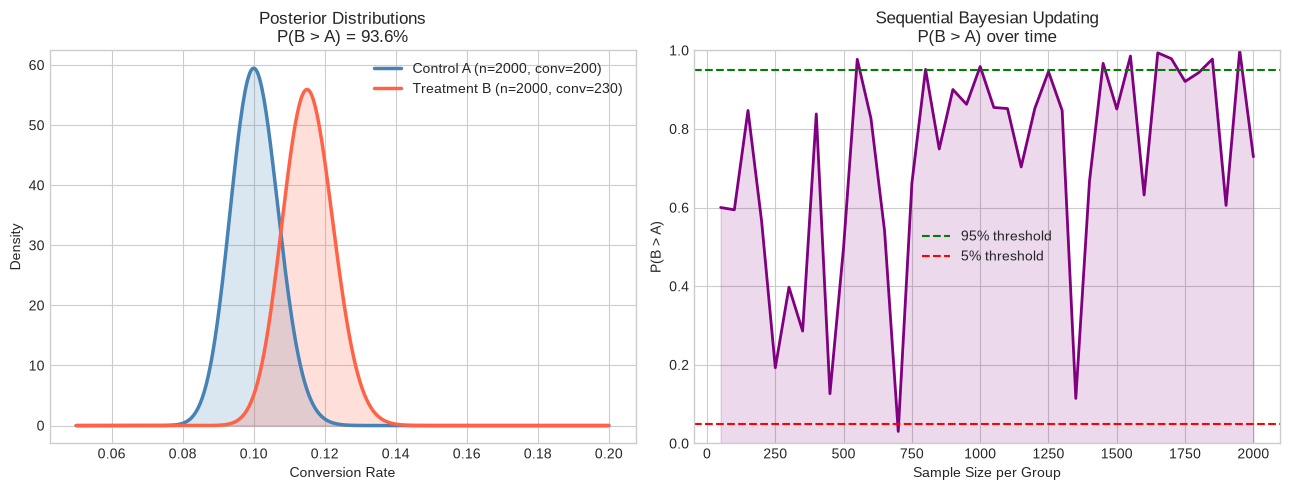

In [7]:
class BayesianABTest:
    def __init__(self, prior_alpha=1, prior_beta=1):
        self.prior_alpha = prior_alpha
        self.prior_beta = prior_beta

    def update(self, n_trials, n_conversions):
        """Return posterior Beta parameters given observed data."""
        post_alpha = self.prior_alpha + n_conversions
        post_beta = self.prior_beta + n_trials - n_conversions
        return post_alpha, post_beta

    def prob_b_beats_a(self, n_a, conv_a, n_b, conv_b, n_samples=50000):
        """Monte Carlo estimate of P(theta_B > theta_A)."""
        alpha_a, beta_a = self.update(n_a, conv_a)
        alpha_b, beta_b = self.update(n_b, conv_b)
        samples_a = np.random.beta(alpha_a, beta_a, n_samples)
        samples_b = np.random.beta(alpha_b, beta_b, n_samples)
        return np.mean(samples_b > samples_a), alpha_a, beta_a, alpha_b, beta_b


# Same experiment as before
n_a = n_b = 2000
conv_a = int(n_a * 0.10)  # 10% conversion
conv_b = int(n_b * 0.115) # 11.5% conversion

bayes = BayesianABTest(prior_alpha=1, prior_beta=1)
prob_b_wins, a_a, a_b, b_a, b_b = bayes.prob_b_beats_a(n_a, conv_a, n_b, conv_b)

print(f'Bayesian P(B > A): {prob_b_wins:.4f} ({prob_b_wins:.1%})')

# Plot posterior distributions
x = np.linspace(0.05, 0.20, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pdf_a = beta_dist.pdf(x, a_a, a_b)
pdf_b = beta_dist.pdf(x, b_a, b_b)

axes[0].plot(x, pdf_a, 'steelblue', linewidth=2.5, label=f'Control A (n={n_a}, conv={conv_a})')
axes[0].plot(x, pdf_b, 'tomato', linewidth=2.5, label=f'Treatment B (n={n_b}, conv={conv_b})')
axes[0].fill_between(x, pdf_a, alpha=0.2, color='steelblue')
axes[0].fill_between(x, pdf_b, alpha=0.2, color='tomato')
axes[0].set_title(f'Posterior Distributions\nP(B > A) = {prob_b_wins:.1%}', fontsize=12)
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Density')
axes[0].legend()

# Sequential Bayesian updating
ns = range(50, 2001, 50)
probs_seq = []
true_p_a_seq = 0.10
true_p_b_seq = 0.115
for n in ns:
    ca = np.random.binomial(n, true_p_a_seq)
    cb = np.random.binomial(n, true_p_b_seq)
    p, *_ = bayes.prob_b_beats_a(n, ca, n, cb)
    probs_seq.append(p)

axes[1].plot(list(ns), probs_seq, 'purple', linewidth=2)
axes[1].axhline(0.95, color='green', linestyle='--', label='95% threshold')
axes[1].axhline(0.05, color='red', linestyle='--', label='5% threshold')
axes[1].fill_between(list(ns), probs_seq, alpha=0.15, color='purple')
axes[1].set_title('Sequential Bayesian Updating\nP(B > A) over time', fontsize=12)
axes[1].set_xlabel('Sample Size per Group')
axes[1].set_ylabel('P(B > A)')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('bayesian_ab.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 7. Multi-Armed Bandit — Adaptive Experimentation

A/B testing splits traffic **equally** and waits — we keep sending traffic to the losing arm. **Multi-armed bandits** adaptively route more traffic to better-performing arms while still exploring.

**Thompson Sampling**: Maintain a Beta posterior for each arm. At each step:
1. Sample $\theta_k \sim \text{Beta}(\alpha_k, \beta_k)$ for each arm $k$
2. Pull arm $k^* = \arg\max_k \theta_k$
3. Update $\alpha_{k^*}$ (if success) or $\beta_{k^*}$ (if failure)

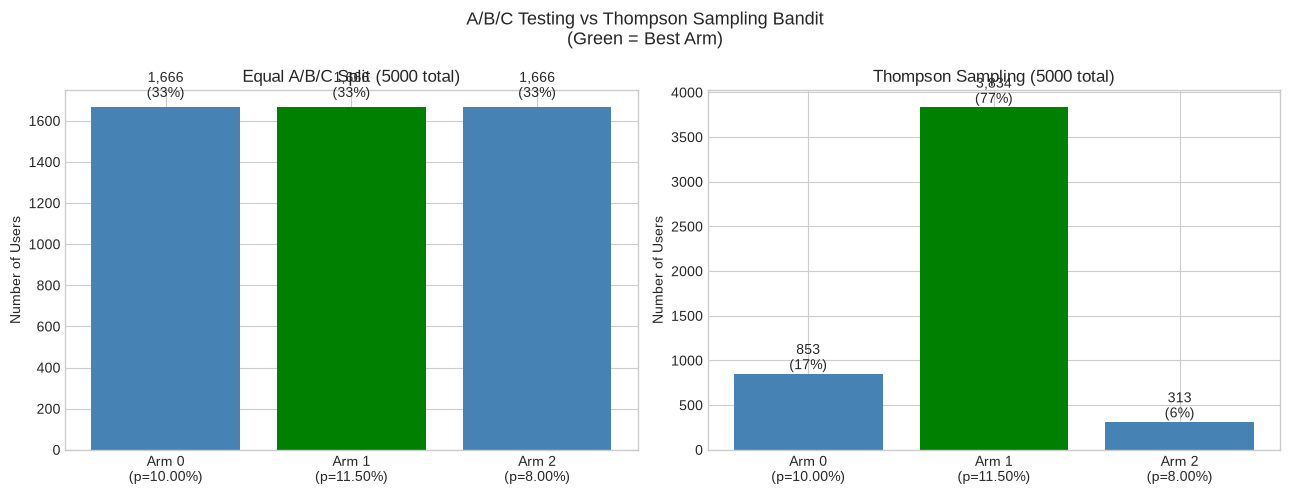

Best arm: 1 (true rate 11.5%)
Thompson Sampling allocations: ['17%', '77%', '6%']
Equal split allocations:       ['33%', '33%', '33%']


In [8]:
class ThompsonSamplingBandit:
    def __init__(self, n_arms):
        self.alpha = np.ones(n_arms)  # successes + 1
        self.beta = np.ones(n_arms)   # failures + 1
        self.n_arms = n_arms
        self.counts = np.zeros(n_arms)

    def select_arm(self):
        samples = np.random.beta(self.alpha, self.beta)
        return np.argmax(samples)

    def update(self, arm, reward):
        if reward == 1:
            self.alpha[arm] += 1
        else:
            self.beta[arm] += 1
        self.counts[arm] += 1

    def arm_allocation(self):
        return self.counts / self.counts.sum()


# Three variants with different true conversion rates
true_rates = [0.10, 0.115, 0.08]  # B is best!
n_arms = len(true_rates)
T = 5000  # total trials

bandit = ThompsonSamplingBandit(n_arms)
arm_history = []

for t in range(T):
    arm = bandit.select_arm()
    reward = np.random.binomial(1, true_rates[arm])
    bandit.update(arm, reward)
    arm_history.append(arm)

# Compare with equal split
equal_splits = np.array([T//n_arms] * n_arms)
bandit_splits = bandit.counts.astype(int)
labels = [f'Arm {i}\n(p={r:.2%})' for i, r in enumerate(true_rates)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['steelblue' if i != 1 else 'green' for i in range(n_arms)]
for ax, splits, title in [
    (axes[0], equal_splits, f'Equal A/B/C Split ({T} total)'),
    (axes[1], bandit_splits, f'Thompson Sampling ({T} total)')
]:
    bars = ax.bar(labels, splits, color=colors)
    for bar, v in zip(bars, splits):
        ax.text(bar.get_x()+bar.get_width()/2, v+50, f'{v:,}\n({v/T:.0%})',
                ha='center', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Number of Users')

plt.suptitle('A/B/C Testing vs Thompson Sampling Bandit\n(Green = Best Arm)', fontsize=13)
plt.tight_layout()
plt.savefig('bandit_vs_ab.png', dpi=80, bbox_inches='tight')
plt.show()

print(f'Best arm: {np.argmax(true_rates)} (true rate {max(true_rates):.1%})')
print(f'Thompson Sampling allocations: {[f"{a:.0%}" for a in bandit.arm_allocation()]}')
print(f'Equal split allocations:       {[f"{1/n_arms:.0%}"]*n_arms}')

---
## 8. Key Pitfalls Checklist

| Pitfall | Problem | Fix |
|---------|---------|-----|
| **Peeking** | Inflated Type I error | Pre-register stopping criteria |
| **SUTVA violation** | Users interact (social network effects) | Cluster randomization |
| **Novelty effect** | New feature gets attention boost | Run until novelty wears off |
| **Simpson's paradox** | Lurking variable reverses result | Stratify analysis |
| **Multiple metrics** | HARKing — pick best metric post-hoc | Pre-register primary metric |
| **Imbalanced groups** | Randomization failed | Check covariate balance |
| **Network effects** | Control users see treatment | Geo/cluster experiments |
| **Underpowered test** | Can't detect real effects | Calculate sample size first |

---
## Additional Learning Resources

| Resource | Type | Description |
|----------|------|-------------|
| **Trustworthy Online Controlled Experiments (Kohavi et al.)** | Book | The definitive A/B testing reference from Microsoft, Google, Airbnb |
| **Evan Miller's A/B Testing Calculator** | Tool | Quick sample size calculations |
| **Netflix Tech Blog — Experimentation** | Blog | How Netflix runs experiments at scale |
| **Uber's Experimentation Platform** | Blog | Large-scale A/B testing at Uber |
| **statsmodels proportions_ztest** | Docs | Python implementation |
| **Bayesian A/B Testing (VWO blog)** | Blog | Bayesian vs Frequentist comparison |
| **Thompson Sampling Tutorial (Russo et al.)** | Paper | A Tutorial on Thompson Sampling (arXiv 2017) |
| **Sequential Analysis — Wald** | Classic | Foundation of sequential testing |